### **a Hipótese principal é verificar se a idade do jogador influencia o tipo de lesão sofrida, ou seja, se espera que a distribuição entre as categorias de lesão seja diferente para jogadores mais jovens e mais velhos**



---



In [1]:
import pandas as pd # manipulação de dataframes
import numpy as np # trabalhar com números de forma eficiente, manipulação de arrays
import matplotlib.pyplot as plt # fazer gráficos
import seaborn as sns# fazer gráficos
import statsmodels.api as sm # estatística, econometria e modelagem preditiva.
from scipy.stats import kruskal # estatística



---



### **Carrega o dataset**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/PedroLovatto99/ciencia-dados-trabalho_EDA/refs/heads/main/full_dataset_thesis%20-%201.csv')



---



### **Variáveis do dataset**

**Season**: Temporada em que ocorreu a lesão

**Injury**: tipo da lesão ou razão do afastamento (como covid)

**Days**: a quantidade de dias que o jogador ficou indisponível pra jogar

**Games missed:** quantidade de partidas que o jogador perdeu por conta da lesão/afastamento

**injury_from_parsed:** data de início da lesão

**injury_until_parsed:** data de término da lesão

**player_name:** nome do jogador

**player_age:** idade do jogador

**player_position:** posição do jogador

**club:** clube do jogador

**league:** liga em que o clube joga



---



### **Colunas renomeadas para português, para facilitar a leitura**

In [3]:
df = df.rename(columns={
    'Season': 'temporada',
    'Injury': 'lesao',
    'Days': 'dias_parado',
    'Games missed': 'jogos_perdidos',
    'injury_from_parsed': 'data_inicio_lesao',
    'injury_until_parsed': 'data_fim_lesao',
    'player_name': 'nome_jogador',
    'player_age': 'idade_jogador',
    'player_position': 'posicao',
    'club': 'clube',
    'league': 'liga'
})

df.head(10)


,temporada,lesao,dias_parado,jogos_perdidos,data_inicio_lesao,data_fim_lesao,nome_jogador,idade_jogador,posicao,clube,liga
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
5,20/21,Fitness,48 days,11,2/1/2021,3/20/2021,Tanguy Nianzou,19,Centre-Back,Bayern Munich,Bundesliga
6,20/21,Torn muscle bundle,52 days,10,12/11/2020,1/31/2021,Tanguy Nianzou,19,Centre-Back,Bayern Munich,Bundesliga
7,20/21,Hamstring injury,61 days,15,9/8/2020,11/7/2020,Tanguy Nianzou,19,Centre-Back,Bayern Munich,Bundesliga
8,20/21,Torn muscle fiber,19 days,1,8/23/2020,9/10/2020,Jérôme Boateng,32,Centre-Back,Bayern Munich,Bundesliga
9,20/21,Hamstring injury,74 days,3,4/26/2021,7/8/2021,Chris Richards,21,Centre-Back,Bayern Munich,Bundesliga




---



# **Sumarização**

In [4]:
def generate_summary(df):
    summary = pd.DataFrame({
        'tipo': df.dtypes,
        'nulos': df.isnull().sum(),
        '%_nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'zeros': (df == 0).sum(),
        'unicos': df.nunique()
    })
    return summary

generate_summary(df)

,tipo,nulos,%_nulos,zeros,unicos
temporada,object,0,0.0,0,5
lesao,object,0,0.0,0,276
dias_parado,object,0,0.0,0,374
jogos_perdidos,int64,0,0.0,0,77
data_inicio_lesao,object,0,0.0,0,1729
data_fim_lesao,object,0,0.0,0,1737
nome_jogador,object,0,0.0,0,4081
idade_jogador,int64,0,0.0,0,28
posicao,object,0,0.0,0,14
clube,object,0,0.0,0,145


### A tabela de sumarização mostra que o dataset não possui dados nulos em nenhuma coluna, mas a variável como *dias_parado* está como object (Texto) quando deveria ser int, isso será corrigido em sequência.



---



# **Tratamento**
*dias_parado* tem a palavra "Days" removido e o valor é convertido para int.

In [5]:
df['dias_parado'] = df['dias_parado'].str.extract(r'(\d+)').astype(int)


def generate_summary(df):
    summary = pd.DataFrame({
        'tipo': df.dtypes,
        'nulos': df.isnull().sum(),
        '%_nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'zeros': (df == 0).sum(),
        'unicos': df.nunique()
    })
    return summary

generate_summary(df)

,tipo,nulos,%_nulos,zeros,unicos
temporada,object,0,0.0,0,5
lesao,object,0,0.0,0,276
dias_parado,int64,0,0.0,0,374
jogos_perdidos,int64,0,0.0,0,77
data_inicio_lesao,object,0,0.0,0,1729
data_fim_lesao,object,0,0.0,0,1737
nome_jogador,object,0,0.0,0,4081
idade_jogador,int64,0,0.0,0,28
posicao,object,0,0.0,0,14
clube,object,0,0.0,0,145


### **Rodando a tabela de sumarização novamente, é possível notar que a coluna *dias_parado* mudou de tipo.**



---



# **Análise Univariada**

### A tabela de sumarização anterior mostrou que o dataset tem 6 colunas numéricas e 5 categóricas. Informações como média e assimetria não fazem sentido para colunas categóricas, e frequência e moda não fazem sentido para numéricas, por isso, sera usado duas funções separadas: a *describe_numericas* e a *describe_categoricas*.

In [6]:
def describe_numericas(df):
    df_num = df.select_dtypes(include=[np.number])
    desc = df_num.describe().T
    desc['mediana'] = df_num.median()
    desc['IQR'] = df_num.quantile(0.75) - df_num.quantile(0.25)
    desc['skew'] = df_num.skew().round(2)
    desc['unicos'] = df_num.nunique()
    desc['zeros'] = (df_num == 0).sum()
    desc['nulos'] = df_num.isnull().sum()
    desc['%_nulos'] = (df_num.isnull().sum() / len(df) * 100).round(2)

    colunas_ordem = ['nulos', '%_nulos', 'unicos', 'zeros', 'skew',
                      'mean', 'min', '25%', 'mediana', '75%', 'max', 'std', 'IQR']

    return desc[colunas_ordem].round(2)


def describe_categoricas(df):
    df_cat = df.select_dtypes(include=['object'])
    desc = df_cat.describe().T
    desc['nulos'] = df_cat.isnull().sum()
    desc['%_nulos'] = (df_cat.isnull().sum() / len(df) * 100).round(2)

    colunas_ordem = ['nulos', '%_nulos', 'unique', 'top', 'freq']
    return desc[colunas_ordem]


print("NUMÉRICAS")
display(describe_numericas(df))

print("\nCATEGÓRICAS")
display(describe_categoricas(df))

NUMÉRICAS


,nulos,%_nulos,unicos,zeros,skew,mean,min,25%,mediana,75%,max,std,IQR
dias_parado,0,0.0,374,0,4.63,36.10,1.0,9.0,18.0,39.0,1013.0,54.42,30.0
jogos_perdidos,0,0.0,77,0,4.41,5.51,1.0,1.0,3.0,6.0,145.0,7.64,5.0
idade_jogador,0,0.0,28,0,0.27,26.55,16.0,23.0,26.0,30.0,43.0,4.40,7.0



CATEGÓRICAS


,nulos,%_nulos,unique,top,freq
temporada,0,0.0,5,21/22,3406
lesao,0,0.0,276,Hamstring injury,1256
data_inicio_lesao,0,0.0,1729,1/3/2022,38
data_fim_lesao,0,0.0,1737,6/30/2023,67
nome_jogador,0,0.0,4081,Carney Chukwuemeka,21
posicao,0,0.0,14,Centre-Back,3139
clube,0,0.0,145,Bayern Munich,349
liga,0,0.0,5,Serie A,4097


- ### A tabela numérica mostra assimetria alta em *dias_parado* (skew=4.63) e *jogos_perdidos* (skew=4.41), com a média bem acima da mediana nos dois casos (36.10 vs 18.0 dias; 5.51 vs 3.0 jogos), ou seja, é um sinal de uma cauda de casos graves distorcendo a média. idade_jogador é a mais próxima da simetria (skew=0.27), com média e mediana praticamente iguais (26.55 vs 26.0).

- ### Na tabela categórica, *lesao* tem 276 valores únicos e *clube* tem 145 categorias, mostrando que aparecem bastante fragmentadas. *lesao* será tratada adiante, agrupada em categorias mais amplas. *nome_jogador* (4.081 valores únicos) é um identificador, não uma variável para análise categórica.



---



### **Para complementar a tabela de sumarização, cada variável numérica é analisada com três visualizações: histograma (forma da distribuição), boxplot (quartis e outliers) e QQ-plot (aderência à normalidade)**

Análise de dias_parado | Skewness: 4.63


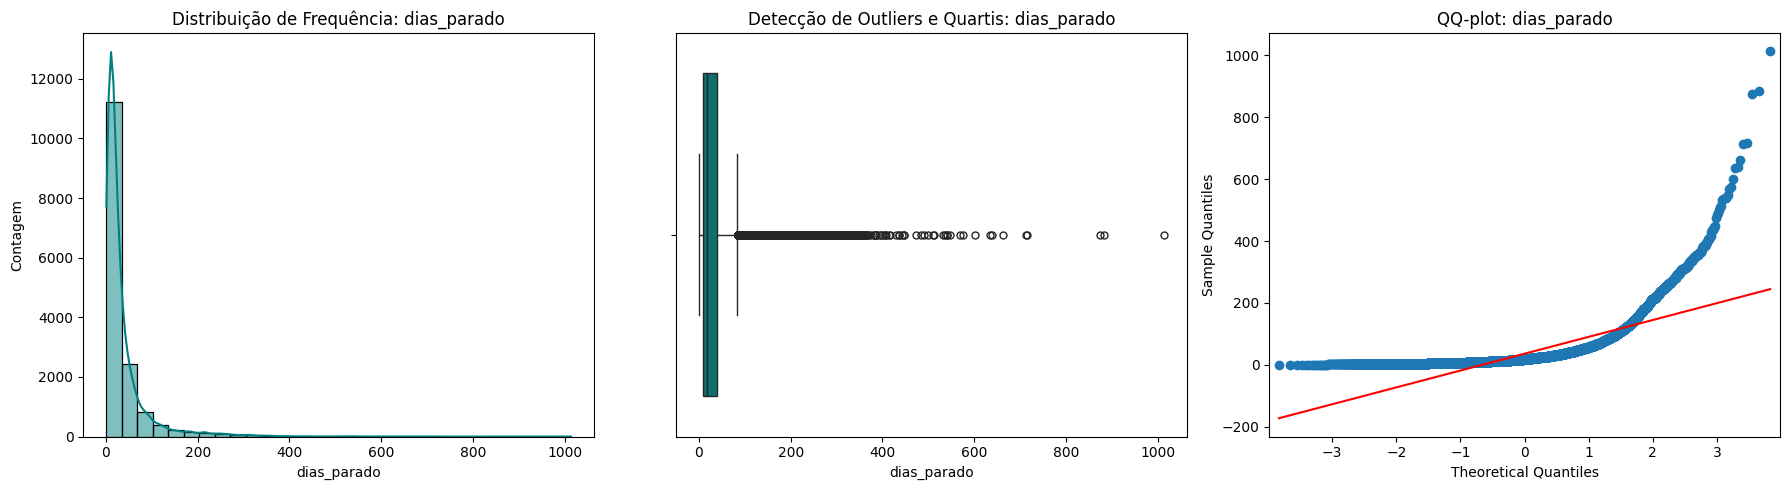

Análise de jogos_perdidos | Skewness: 4.41


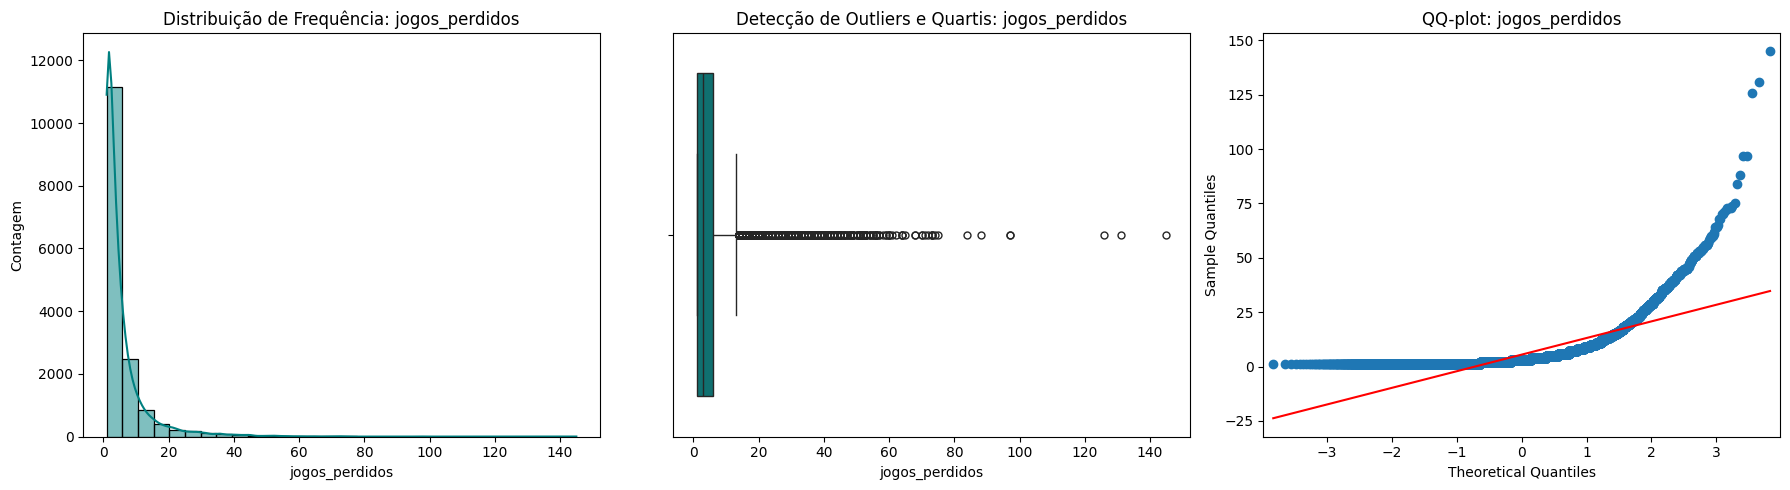

Análise de idade_jogador | Skewness: 0.27


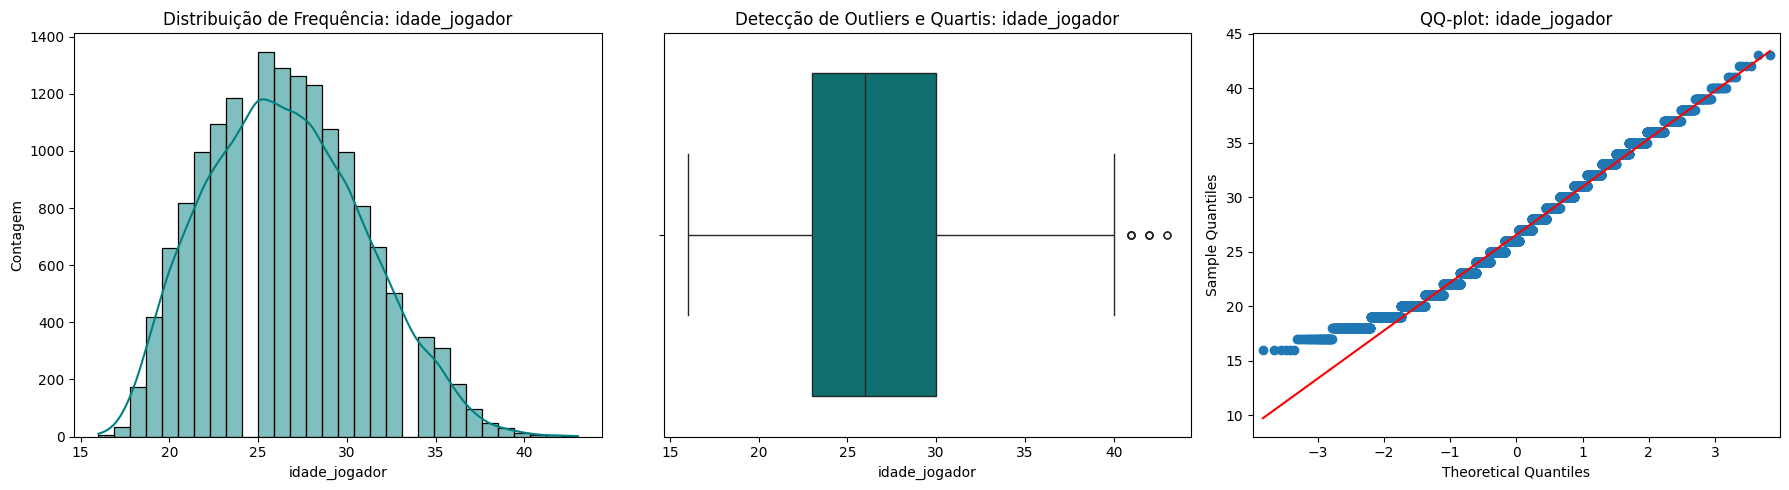

In [7]:
colunas_numericas = df.select_dtypes(include=[np.number]).columns

for col in colunas_numericas:
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribuição de Frequência: {col}')
    plt.xlabel(col)
    plt.ylabel('Contagem')

    plt.subplot(1, 3, 2)
    sns.boxplot(x=df[col], color='teal', fliersize=5)
    plt.title(f'Detecção de Outliers e Quartis: {col}')

    plt.subplot(1, 3, 3)
    sm.qqplot(df[col], line='s', ax=plt.gca())
    plt.title(f'QQ-plot: {col}')

    print(f"Análise de {col} | Skewness: {df[col].skew():.2f}")

    plt.tight_layout()
    plt.show()
    print("=" * 100)

### Os três gráficos confirmam o que a tabela de sumarização já indicava. *dias_parado* (skew=4.63) e *jogos_perdidos* (skew=4.41) apresentam histogramas fortemente concentrados em valores baixos, com uma cauda longa se estendendo até valores extremos (1013 dias e 145 jogos, respectivamente).  Os boxplots mostram essa cauda como uma grande quantidade de outliers, e os QQ-plots mostram os pontos se afastando da linha de normalidade nos quantis superiores. *idade_jogador* (skew=0.27) se comporta de forma bem diferente, histograma próximo do formato de sino, boxplot com poucos outliers, e QQ-plot acompanhando a linha de normalidade de perto ao longo de quase toda a distribuição, com um leve desvio apenas na extremidade inferior.



---



### Assim como as numéricas, as variáveis categóricas são analisadas com gráfico de barras e tabela de frequência absoluta, para identificar desbalanceamento entre categorias e colunas fragmentadas (muitas categorias, muitas delas raras). *nome_jogador* foi excluída do loop por ser identificador sem valor analítico. A ordem de exibição prioriza as colunas com poucas categorias, deixando *lesao* e *clube* por último.

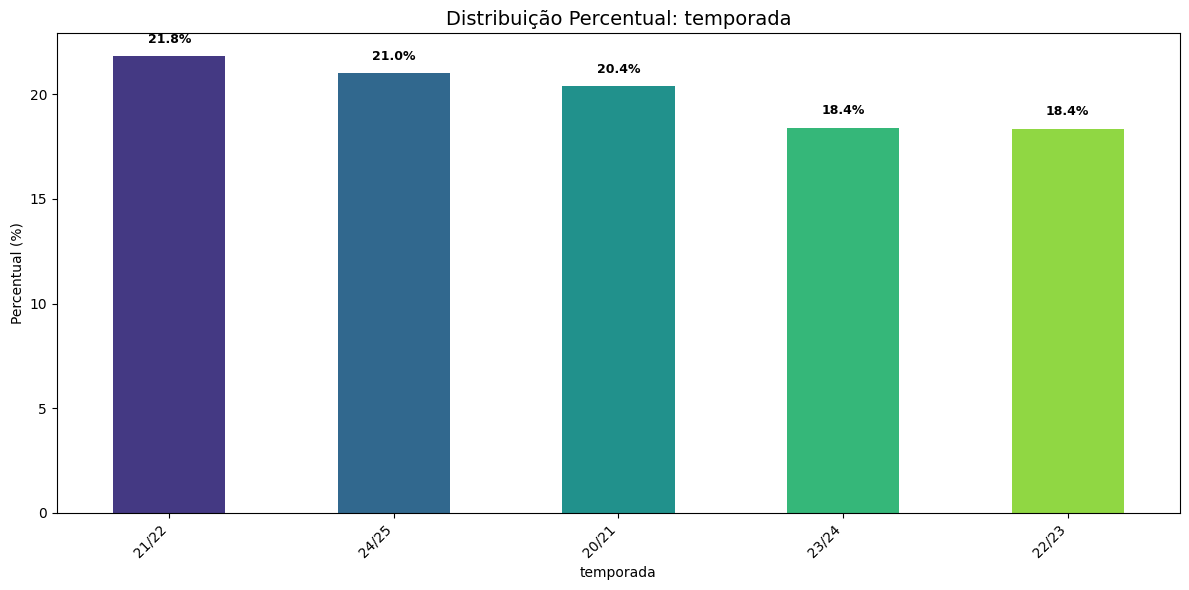

Tabela de Frequência Absoluta - temporada:


,Quantidade (n)
temporada,
21/22,3406
24/25,3279
20/21,3181
23/24,2873
22/23,2864


--------------------------------------------------------------------------------


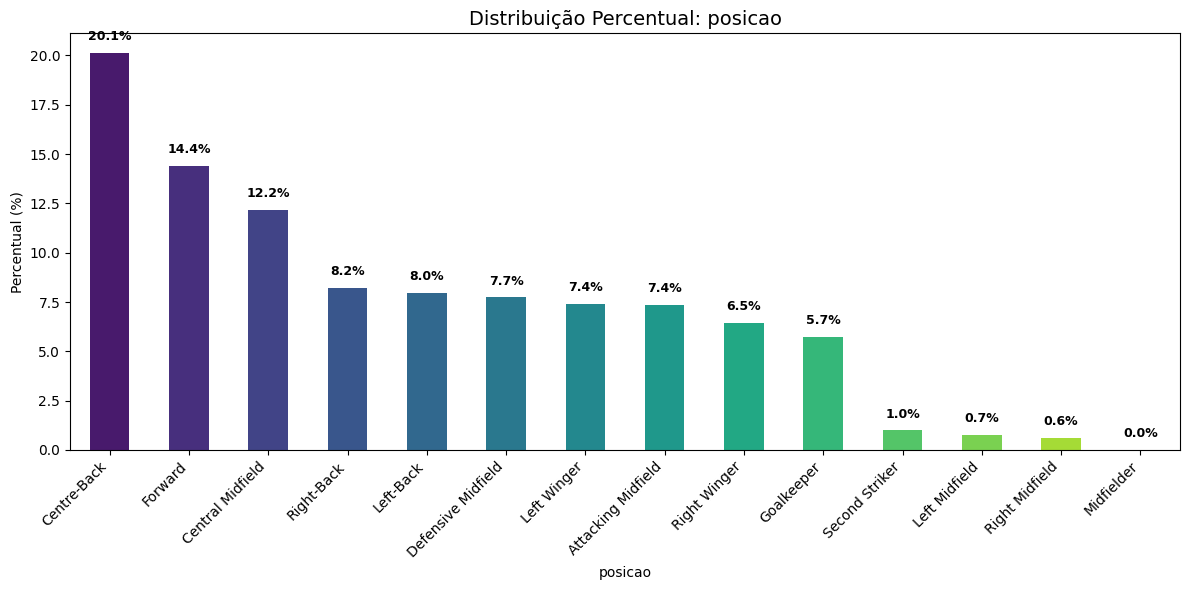

Tabela de Frequência Absoluta - posicao:


,Quantidade (n)
posicao,
Centre-Back,3139
Forward,2246
Central Midfield,1902
Right-Back,1283
Left-Back,1245
Defensive Midfield,1207
Left Winger,1157
Attacking Midfield,1150
Right Winger,1008


--------------------------------------------------------------------------------


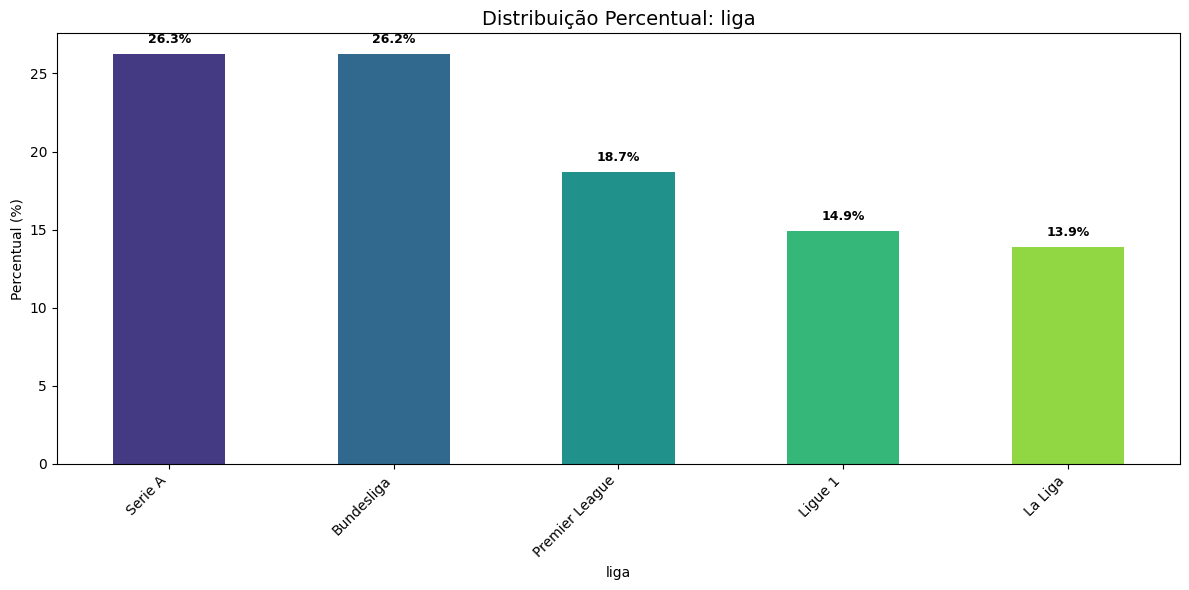

Tabela de Frequência Absoluta - liga:


,Quantidade (n)
liga,
Serie A,4097
Bundesliga,4094
Premier League,2914
Ligue 1,2330
La Liga,2168


--------------------------------------------------------------------------------


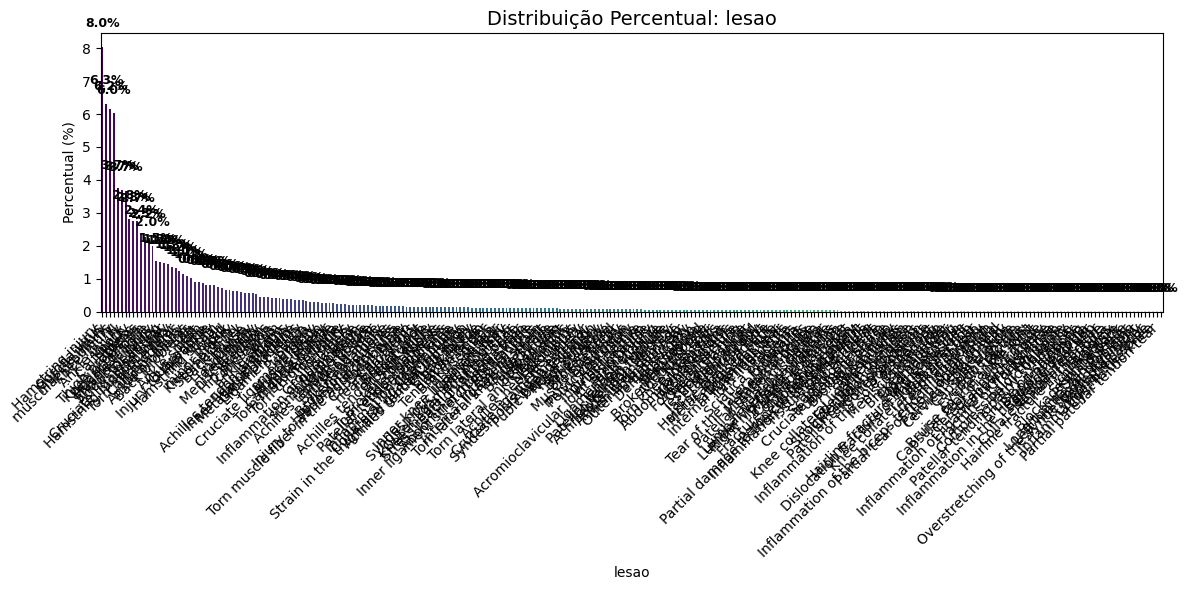

Tabela de Frequência Absoluta - lesao:


,Quantidade (n)
lesao,
Hamstring injury,1256
Corona virus,986
Muscle injury,960
muscular problems,940
Knee injury,584
...,...
Vertebral injury,1
Lymphatic cancer,1
Inflammation in the spine,1


--------------------------------------------------------------------------------


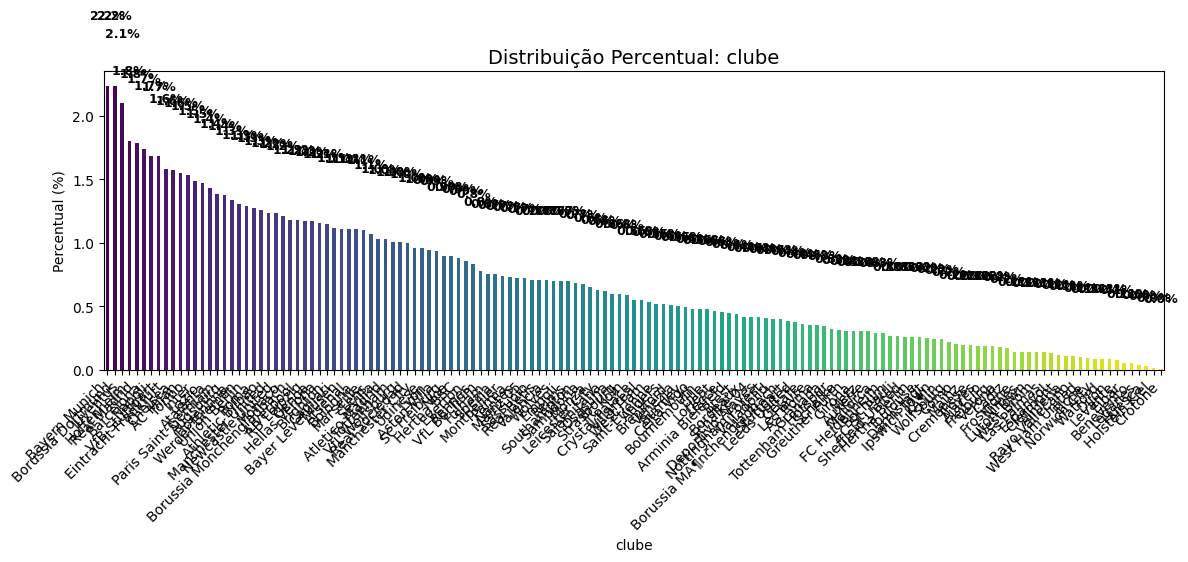

Tabela de Frequência Absoluta - clube:


,Quantidade (n)
clube,
Bayern Munich,349
Borussia Dortmund,349
Juventus,327
Hoffenheim,281
Real Madrid,278
...,...
Benevento,8
Leganes,6
Huesca,5


--------------------------------------------------------------------------------


In [8]:
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
colunas_categoricas.remove('nome_jogador')

ordem = ['temporada', 'posicao', 'liga', 'lesao', 'clube']
colunas_categoricas = [c for c in ordem if c in colunas_categoricas]

for col in colunas_categoricas:
    plt.figure(figsize=(12, 6))

    contagem_absoluta = df[col].value_counts()
    dist_pct = (contagem_absoluta / len(df)) * 100

    dist_pct.plot(kind='bar', color=sns.color_palette('viridis', len(dist_pct)))

    for i, valor in enumerate(dist_pct):
        plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.title(f'Distribuição Percentual: {col}', fontsize=14)
    plt.ylabel('Percentual (%)')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"Tabela de Frequência Absoluta - {col}:")
    display(contagem_absoluta.to_frame(name='Quantidade (n)'))
    print("-" * 80)

### *temporada* e *liga* mostram uma distribuição mais equilibrada em 5 categorias, enquanto posição tem 14 categorias, com algumas abaixo de 1% que devem ser agrupadas em "Outros" antes de qualquer teste envolvendo essa variável.

### *lesao* (com 276 categorias) e *clube* (com 145 categorias) resultam em gráficos impossíveis de ler, com muitos valores ficando sobrepostos, o que confirma a fragmentação citada antes. Por conta disso, *lesao* será agrupada em categoria_lesao na etapa seguinte

-----------------------------------

### Por conta da alta fragmentação de lesao na etapa anterior, as lesões serão organizadas em 7 categorias: Muscular, Articular/ligamentar, Óssea, Pé, Costas, Cabeça e outras (para casos que não se encaixam nas outras). Registros de doenças, como covid, foram removidos do dataset, já que o foco são as lesões físicas.

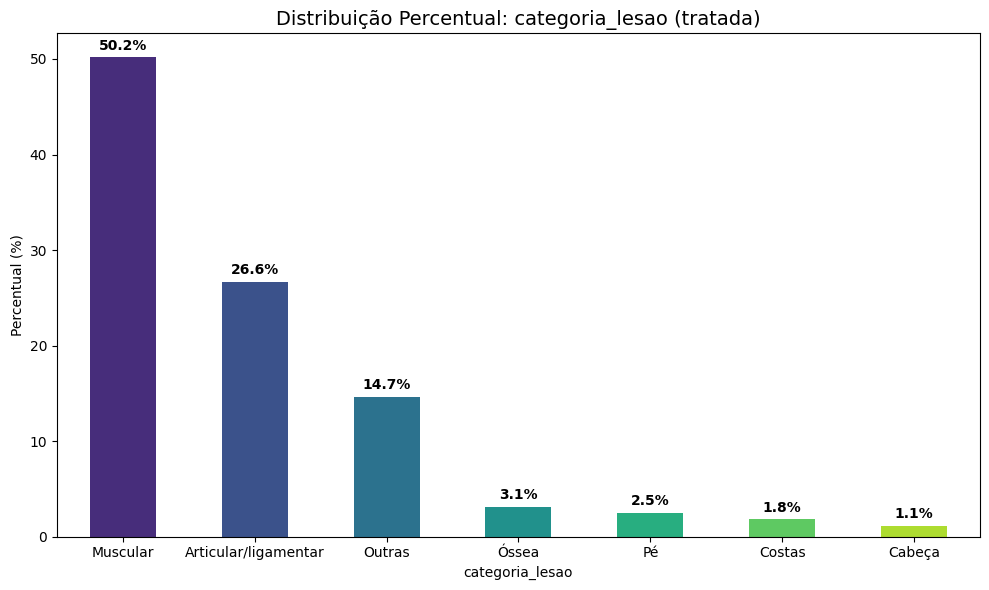

In [9]:
def categoria_lesao(texto):
    texto = str(texto).lower()
    doenca = ['corona', 'ill', 'flu', 'cold', 'fever', 'quarantine', 'stomach', 'virus', 'infection']
    muscular = ['muscle', 'muscular', 'hamstring', 'calf', 'thigh', 'adductor', 'groin', 'strain',
                'fiber', 'bundle', 'dead leg', 'pubalgia', 'lumbago']
    articular = ['knee', 'ankle', 'ligament', 'cruciate', 'meniscus', 'achilles',
                 'shoulder', 'hip', 'capsular', 'joint']
    ossea = ['fracture', 'broken', 'bone']
    pe = ['foot', 'toe', 'heel']
    costas = ['back']
    cabeca = ['head', 'concussion']

    for kw in doenca:
        if kw in texto:
            return 'Doença/Infecção'
    for kw in muscular:
        if kw in texto:
            return 'Muscular'
    for kw in articular:
        if kw in texto:
            return 'Articular/ligamentar'
    for kw in ossea:
        if kw in texto:
            return 'Óssea'
    for kw in pe:
        if kw in texto:
            return 'Pé'
    for kw in costas:
        if kw in texto:
            return 'Costas'
    for kw in cabeca:
        if kw in texto:
            return 'Cabeça'
    return 'Outras'

df['categoria_lesao'] = df['lesao'].apply(categoria_lesao)
df = df[df['categoria_lesao'] != 'Doença/Infecção'].copy()

plt.figure(figsize=(10, 6))
contagem = df['categoria_lesao'].value_counts()
dist_pct = (contagem / len(df)) * 100
dist_pct.plot(kind='bar', color=sns.color_palette('viridis', len(dist_pct)))
for i, valor in enumerate(dist_pct):
    plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Distribuição Percentual: categoria_lesao (tratada)', fontsize=14)
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### A categorização resultou em: Muscular (6.536 casos), Articular/ligamentar (3.469), Outras (1.910), Óssea (406), Pé (322), Costas (235) e Cabeça (148), após a remoção de 2.577 registros de doença ou infecção. Não foram criadas mais categorias para evitar criar categorias com volumes insuficientes para testes confiáveis



---



### Para testar a hipótese principal, *idade_jogador* (28 valores distintos) será agrupada em 5 faixas etárias, permitindo o cruzamento com *categoria_lesao* em uma tabela de contingência e o teste qui-quadrado. Os cortes buscam refletir etapas de carreira: até 20 (formação/início), 21-24 (transição), 25-28 (auge), 29-32 (pós-auge) e 33+ (fase final).

faixa_etaria
até 20    1063
21-24     3424
25-28     4289
29-32     2961
33+       1289
Name: count, dtype: int64


categoria_lesao,Articular/ligamentar,Cabeça,Costas,Muscular,Outras,Pé,Óssea
faixa_etaria,,,,,,,
até 20,34.4,1.8,1.5,40.9,15.8,1.6,4.0
21-24,31.2,1.1,1.6,45.3,14.3,3.0,3.4
25-28,26.0,1.2,1.4,51.4,14.7,2.4,3.1
29-32,22.3,1.0,2.1,55.2,13.8,2.5,3.1
33+,20.2,1.1,3.3,55.2,16.6,1.9,1.8


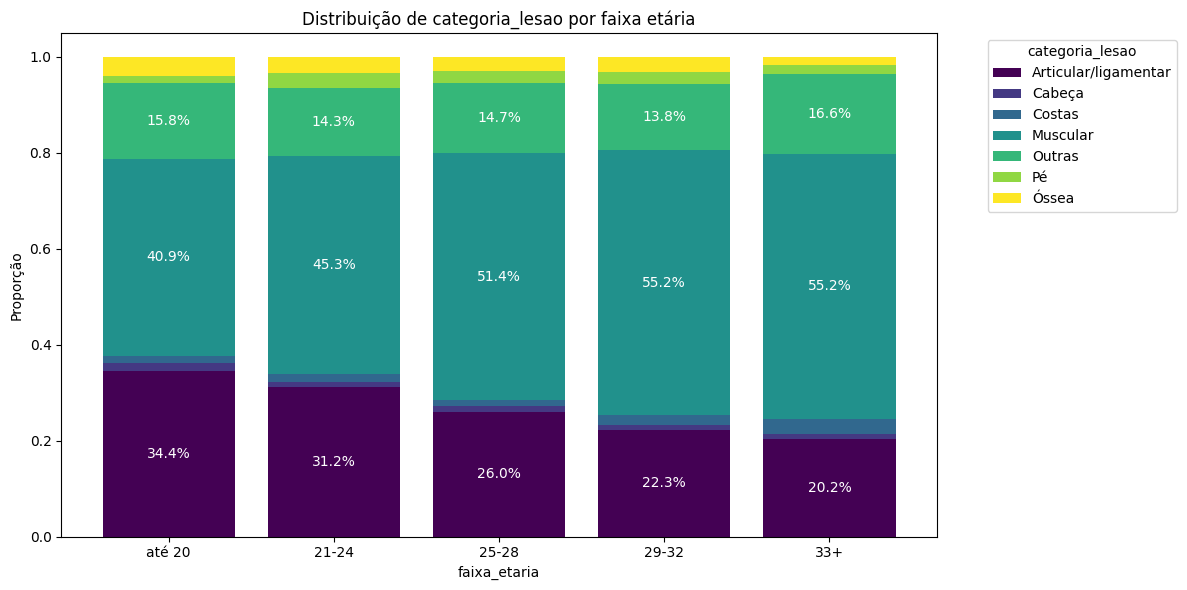

categoria_lesao,Articular/ligamentar,Cabeça,Costas,Muscular,Outras,Pé,Óssea
faixa_etaria,,,,,,,
até 20,366,19,16,435,168,17,42
21-24,1069,36,56,1552,490,104,117
25-28,1114,50,59,2203,630,102,131
29-32,659,29,62,1635,408,75,93
33+,261,14,42,711,214,24,23


qui-quadrado = 203.37, p-valor = 2.3267e-30, graus de liberdade = 24


In [10]:
from scipy.stats import chi2_contingency

# 1. Cria a faixa etária (cobre todas as idades do dataset, de 16 a 43)
df['faixa_etaria'] = pd.cut(df['idade_jogador'],
                            bins=[0, 20, 24, 28, 32, 100],
                            labels=['até 20', '21-24', '25-28', '29-32', '33+'])
print(df['faixa_etaria'].value_counts().sort_index())

# 2. Tabela percentual (por faixa) + gráfico de barras empilhadas
ct_pct = pd.crosstab(df['faixa_etaria'], df['categoria_lesao'], normalize='index')
display((ct_pct * 100).round(1))

ax = ct_pct.plot(kind='bar', stacked=True, width=0.8, figsize=(12, 6), colormap='viridis')
for barra in ax.patches:
    width = barra.get_width()    # largura da barra
    height = barra.get_height()  # altura da fatia (proporção)
    x, y = barra.get_xy()        # posição da fatia
    if height > 0.05:            # só escreve nas fatias maiores que 5%
        ax.text(x + width / 2, y + height / 2, f'{height:.1%}',
                ha='center', va='center', color='white', fontsize=10)

plt.title('Distribuição de categoria_lesao por faixa etária')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.legend(title='categoria_lesao', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 3. Tabela de contagens brutas + teste qui-quadrado
ct = pd.crosstab(df['faixa_etaria'], df['categoria_lesao'])
display(ct)

chi2, p, dof, esperado = chi2_contingency(ct)
print(f"qui-quadrado = {chi2:.2f}, p-valor = {p:.4e}, graus de liberdade = {dof}")

### A tabela percentual mostra um padrão consistente: a proporção de lesões musculares aumenta com a idade, de 40,9% (até 20 anos) para 55,2% (33+), enquanto a proporção de lesões articulares/ligamentares diminui na mesma direção, de 34,4% para 20,2%. O teste qui-quadrado resultou em qui-quadrado = 203,37, com p-valor ≈ 2,33 × 10⁻³⁰ (24 graus de liberdade), muito abaixo de 0,05, o que indica que é extremamente improvável que essa diferença seja por acaso, o que sustenta que tem sim uma associação estatisticamente significativa entre faixa etária e categoria de lesão. ###



---



### Hipótese Extra: a gravidade da lesão também muda com a idade?



---



### Complementando a descoberta sobre o tipo de lesão, vamos testar se a gravidade (variável *dias_parado*) também varia entre as faixas etária. Como *dias_parado* tem uma assimetria muito alta (skew=4.63), vamos utilizar o teste de Kruskal-Wallis (não paramétrico).

In [11]:
from scipy.stats import kruskal

resumo = df.groupby('faixa_etaria')['dias_parado'].agg(['count', 'mean', 'median'])
display(resumo.round(1))

grupos = [df[df['faixa_etaria']==f]['dias_parado'] for f in df['faixa_etaria'].cat.categories]
h, p = kruskal(*grupos)
print(f"Kruskal-Wallis: H = {h:.2f}, p-valor = {p:.4e}")

/tmp/ipykernel_2288/2076018820.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = df.groupby('faixa_etaria')['dias_parado'].agg(['count', 'mean', 'median'])


,count,mean,median
faixa_etaria,,,
até 20,1063,52.7,29.0
21-24,3424,42.1,23.0
25-28,4289,39.8,22.0
29-32,2961,36.9,21.0
33+,1289,34.2,19.0


Kruskal-Wallis: H = 97.45, p-valor = 3.4269e-20


### Ao contrário do que se poderia esperar por intuição, a gravidade das lesões diminui com a idade. A mediana de dias parado caiu de 29 (até 20 anos) para 19 (33+), uma tendência consistente em todas as faixas. O teste de Kruskal-Wallis confirma que essa diferença é estatisticamente significativa (H = 97,45; p ≈ 3,43 × 10⁻²⁰), rejeitando a hipótese nula de que a gravidade é igual entre as faixas etárias.



---



### Após o teste de Kruskal-wallis onde foi identificado que a gravidade da lesão difere entre faixas etárias, será testado uma correlação entre a variável *idade_jogador* e os *dias_parado*, sem nenhum agrupamento, para verificar se o padrão se confirma de forma independente da escolha das faixas. Como *dias_parado* tem uma assimetria alta (skew=4,63), será utilizado o teste de Spearman.

Spearman: rho = -0.0780, p-valor = 4.7416e-19


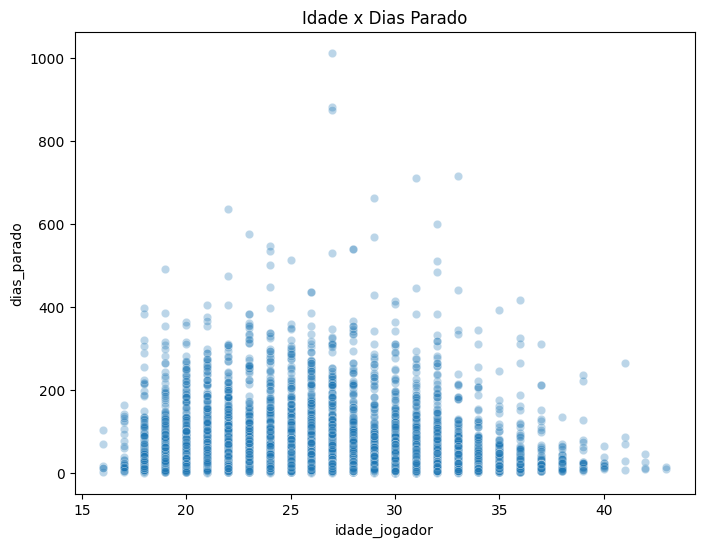

In [12]:
from scipy.stats import spearmanr

rho, p = spearmanr(df['idade_jogador'], df['dias_parado'])
print(f"Spearman: rho = {rho:.4f}, p-valor = {p:.4e}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='idade_jogador', y='dias_parado', alpha=0.3)
plt.title('Idade x Dias Parado')
plt.show()

### A correlação de Spearman é fraca (rho = −0,078), porém estatisticamente significativa (p ≈ 4,74 × 10⁻¹⁹). O sinal negativo confirma a mesma direção encontrada no teste de Kruskal-Wallis, em que a gravidade da lesão tende a cair com a idade. A fraqueza da correlação vem da alta dispersão individual dos dados, para qualquer idade, dias_parado varia de quase zero a centenas de dias. O padrão mais visível no gráfico é que lesões mais graves (300+ dias de afastamento) se concentram entre 20 e 33 anos, desaparecendo após os 37-38 anos.



---



## Planejamento de Feature Engineering

Com base na exploração realizada, as seguintes transformações seriam necessárias antes de qualquer uso do dataset em um modelo preditivo:

**One-Hot Encoding** — *categoria_lesao*, *liga*, *posicao* são
Categóricas nominais, sem ordem natural entre as categorias.

**Codificação ordinal** — *faixa_etaria*
Possui ordem natural (até 20 < 21-24 < 25-28 < 29-32 < 33+), que o One-Hot descartaria.

**Agrupamento de categorias raras em "Outros"** — *posicao*
*Second Striker*, *Left Midfield*, *Right Midfield* e *Midfielder* somam menos de 3% do dataset.

**Transformação logarítmica (log1p)** — *dias_parado*, *jogos_perdidos*
tem Assimetria alta (skew = 4,63 e 4,41), confirmada por histograma, boxplot e QQ-plot.

**Normalização/Padronização** — *idade_jogador*, *dias_parado*, *jogos_perdidos*
Necessária apenas se um modelo baseado em distância (ex: K-Means, KNN) for utilizado — escalas muito diferentes (16–43, 1–1013, 1–145).

**Nenhum tratamento de nulos necessário** — todas as colunas
Dataset sem valores ausentes (confirmado por generate_summary).

**Não deve ser utilizada como variável preditiva** — *nome_jogador*
Identificador único (4.081 valores distintos).

**Já tratada** — *lesao* (original)
Agrupada em *categoria_lesao* (276 categorias, a maioria com poucos casos).

**Alterar o tipo** — *data_inicio_lesao*, *data_fim_lesao*
devem ser convertidas para datetime para conseguir calcular o intervalo.